# Mutual Fund Performance Analytics — 40 Scheme Universe

Full performance analytics suite built on:

- `01_fund_master.csv` — scheme metadata (name, category, expense ratio, benchmark, etc.)
- `02_nav_history.csv` — daily NAVs, 2022-01-03 to 2026-05-29, keyed by `amfi_code`
- `10_benchmark_indices.csv` — daily closes for NIFTY50, NIFTY100, and 5 other indices

Sections:

1. Daily returns + distribution sanity checks
2. CAGR (1yr / 3yr / 5yr) comparison table
3. Sharpe Ratio (ranked)
4. Sortino Ratio (ranked)
5. Alpha / Beta vs Nifty 100 (OLS via `scipy.stats.linregress`)
6. Maximum Drawdown + worst drawdown window
7. Composite Fund Scorecard (0–100)
8. Benchmark comparison chart (top 5 funds vs Nifty 50 / Nifty 100) + tracking error

**Before running:** if you place the notebook in a different folder from the CSVs, update `DATA_DIR` in the config cell below. Everything else works out of the box against the files as provided.


In [9]:
# ============================================================
# CONFIG
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

DATA_DIR   = "data"      # folder containing the 3 CSVs below
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FUND_MASTER_FILE = os.path.join(DATA_DIR, "01_fund_master.csv")
NAV_FILE         = os.path.join(DATA_DIR, "02_nav_history.csv")
BENCHMARK_FILE   = os.path.join(DATA_DIR, "10_benchmark_indices.csv")

RF_ANNUAL    = 0.065   # 6.5% RBI repo rate proxy
TRADING_DAYS = 252

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 110


## 0. Load & reshape data

In [10]:
# ---- Fund master (scheme metadata) ----
fund_master = pd.read_csv(FUND_MASTER_FILE)
fund_master = fund_master.set_index("amfi_code")

scheme_name_map = fund_master["scheme_name"]          # amfi_code -> scheme_name
expense_df      = fund_master["expense_ratio_pct"]     # amfi_code -> expense ratio (%)

print(f"Fund master: {len(fund_master)} schemes")
fund_master[["scheme_name", "category", "sub_category", "expense_ratio_pct", "benchmark"]].head()


Fund master: 40 schemes


,scheme_name,category,sub_category,expense_ratio_pct,benchmark
amfi_code,,,,,
119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,1.5400,NIFTY 100 TRI
119552,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,0.6600,NIFTY 100 TRI
119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,1.4300,BSE 250 SmallCap TRI
119599,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,0.7200,BSE 250 SmallCap TRI
119120,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,0.7700,CRISIL Dynamic Gilt Index


In [11]:
# ---- NAV history: long (amfi_code, date, nav) -> wide matrix keyed by scheme_name ----
nav_raw = pd.read_csv(NAV_FILE, parse_dates=["date"])
nav_raw = nav_raw.sort_values(["amfi_code", "date"])

nav_wide = nav_raw.pivot_table(index="date", columns="amfi_code", values="nav")
nav_wide = nav_wide.sort_index().ffill()
nav_wide.columns = [scheme_name_map.get(c, str(c)) for c in nav_wide.columns]

print(f"NAV matrix: {nav_wide.shape[0]} dates x {nav_wide.shape[1]} schemes")
print(f"Date range: {nav_wide.index.min().date()} to {nav_wide.index.max().date()}")
assert nav_wide.shape[1] == 40, f"Expected 40 schemes, found {nav_wide.shape[1]}"
nav_wide.iloc[:3, :4]


NAV matrix: 1150 dates x 40 schemes
Date range: 2022-01-03 to 2026-05-29


,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,ABSL Frontline Equity Fund - Regular - Growth
date,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996
2022-01-04,515.0971,26.2234,105.9447,305.4514
2022-01-05,521.7239,26.2221,105.4800,306.6324


In [12]:
# ---- Benchmark indices: long (date, index_name, close_value) -> wide (Nifty 50 / Nifty 100 etc.) ----
bench_raw = pd.read_csv(BENCHMARK_FILE, parse_dates=["date"])
bench_wide = bench_raw.pivot_table(index="date", columns="index_name", values="close_value").sort_index().ffill()
bench_wide = bench_wide.rename(columns={"NIFTY50": "nifty50", "NIFTY100": "nifty100"})
bench = bench_wide[["nifty50", "nifty100"]]

# align to common trading dates
common_idx = nav_wide.index.intersection(bench.index)
nav_wide = nav_wide.loc[common_idx]
bench = bench.loc[common_idx]

print(f"Aligned on {len(common_idx)} common trading dates")
bench.head()


Aligned on 1150 common trading dates


index_name,nifty50,nifty100
date,,
2022-01-03,"17,492.7900","17,778.2400"
2022-01-04,"17,689.6400","17,537.5200"
2022-01-05,"17,835.0500","17,607.7300"
2022-01-06,"17,878.5100","17,556.0500"
2022-01-07,"17,759.1500","17,664.0200"


In [13]:
# ---- Rebuild expense_df keyed by scheme_name (matches nav_wide columns) ----
expense_df.index = [scheme_name_map.get(c, str(c)) for c in expense_df.index]

missing_expense = set(nav_wide.columns) - set(expense_df.index)
if missing_expense:
    print(f"WARNING: no expense ratio found for {len(missing_expense)} schemes: {sorted(missing_expense)}")
else:
    print("Expense ratios matched for all 40 schemes.")


Expense ratios matched for all 40 schemes.


## 1. Daily Returns

`daily_return = nav_t / nav_t-1 − 1` for every scheme. We validate the distribution afterward (no absurd outliers, roughly centered near zero, reasonable std).

In [14]:
daily_returns = nav_wide.pct_change().dropna(how="all")
bench_returns = bench.pct_change().dropna(how="all")

print("Daily returns shape:", daily_returns.shape)
daily_returns.describe().T[["mean", "std", "min", "max"]].sort_values("std")


Daily returns shape: (1149, 40)


,mean,std,min,max
ICICI Pru Liquid Fund - Regular - Growth,0.0003,0.0003,-0.0007,0.0012
ABSL Liquid Fund - Regular - Growth,0.0002,0.0003,-0.0008,0.0012
Kotak Liquid Fund - Regular - Growth,0.0003,0.0003,-0.0007,0.0013
HDFC Short Term Debt Fund - Regular - Growth,0.0002,0.0025,-0.0082,0.0088
SBI Magnum Gilt Fund - Regular Plan - Growth,0.0002,0.0025,-0.0077,0.0082
Nippon India Gilt Securities Fund - Regular - Growth,0.0002,0.0025,-0.0089,0.0077
UTI Nifty 50 Index Fund - Regular - Growth,0.0007,0.0081,-0.0211,0.0256
Nippon India ETF Nifty 50 BeES,0.0006,0.0082,-0.0255,0.0305
Kotak Bluechip Fund - Regular - Growth,0.0005,0.0085,-0.0238,0.0286
SBI Bluechip Fund - Regular Plan - Growth,0.0009,0.0087,-0.0277,0.0351


No single-day moves > 20% detected — distribution looks clean.


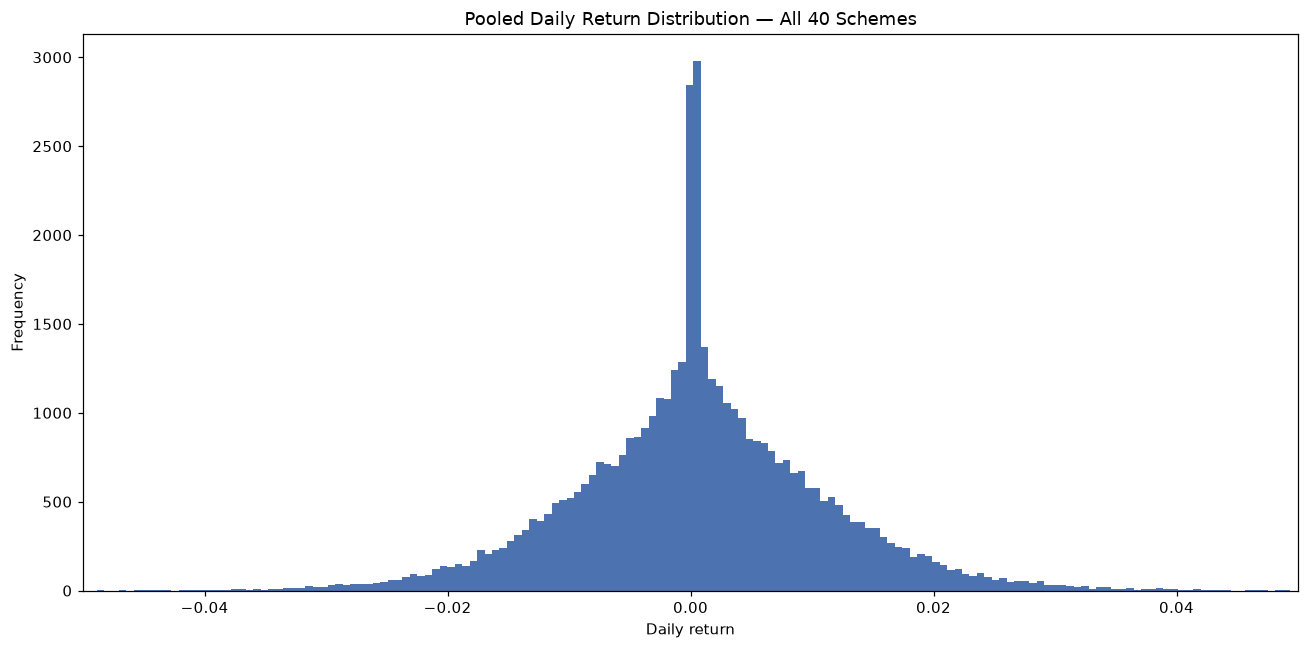

In [15]:
# ---- Distribution sanity checks ----
suspicious = (daily_returns.abs() > 0.20)
flagged = suspicious.sum()
flagged = flagged[flagged > 0]
if len(flagged):
    print("Schemes with >20% single-day moves (investigate for data errors):")
    print(flagged)
else:
    print("No single-day moves > 20% detected — distribution looks clean.")

fig, ax = plt.subplots()
flat = daily_returns.values.flatten()
ax.hist(flat[~np.isnan(flat)], bins=200, color="#4C72B0")
ax.set_xlim(-0.05, 0.05)
ax.set_title("Pooled Daily Return Distribution — All 40 Schemes")
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/daily_return_distribution.png")
plt.show()


## 2. CAGR — 1yr, 3yr, 5yr

`CAGR = (NAV_end / NAV_start) ^ (1/n) − 1`, where `n` uses the actual calendar-day span (days/365.25) between the nearest available start date and the last available date.

In [16]:
def cagr(nav_series, years):
    nav_series = nav_series.dropna()
    if nav_series.empty:
        return np.nan
    end_date = nav_series.index.max()
    start_target = end_date - pd.DateOffset(years=years)
    valid_start_dates = nav_series.index[nav_series.index >= start_target]
    if len(valid_start_dates) == 0 or valid_start_dates.min() > start_target + pd.Timedelta(days=10):
        return np.nan
    start_date = valid_start_dates.min()
    nav_start = nav_series.loc[start_date]
    nav_end = nav_series.loc[end_date]
    n_years = (end_date - start_date).days / 365.25
    if pd.isna(nav_start) or pd.isna(nav_end) or nav_start <= 0 or n_years <= 0:
        return np.nan
    return (nav_end / nav_start) ** (1 / n_years) - 1

cagr_table = pd.DataFrame(index=nav_wide.columns)
for yrs, label in [(1, "CAGR_1yr"), (3, "CAGR_3yr"), (5, "CAGR_5yr")]:
    cagr_table[label] = [cagr(nav_wide[col], yrs) for col in nav_wide.columns]

cagr_table = cagr_table.sort_values("CAGR_3yr", ascending=False)
cagr_table.to_csv(f"{OUTPUT_DIR}/cagr_comparison.csv")
cagr_table.style.format("{:.2%}")


,CAGR_1yr,CAGR_3yr,CAGR_5yr
Axis Midcap Fund - Regular - Growth,22.28%,35.10%,nan%
Mirae Asset Large Cap Fund - Regular - Growth,20.38%,33.99%,nan%
ICICI Pru Bluechip Fund - Direct - Growth,13.07%,32.48%,nan%
HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.28%,32.43%,nan%
ICICI Pru Midcap Fund - Regular - Growth,29.63%,31.77%,nan%
SBI Bluechip Fund - Regular Plan - Growth,60.49%,30.45%,nan%
Kotak Flexicap Fund - Regular - Growth,26.68%,29.58%,nan%
Mirae Asset Tax Saver Fund - Regular - Growth,39.78%,29.17%,nan%
ABSL Frontline Equity Fund - Regular - Growth,47.96%,28.96%,nan%
DSP Small Cap Fund - Regular - Growth,65.20%,26.99%,nan%


## 3. Sharpe Ratio

`Sharpe = (Rp − Rf) / Std(Rp) × √252`

Rp is the mean daily return, Rf = 6.5% annual (converted to a daily rate). Ranked descending (rank 1 = best).

In [17]:
rf_daily = RF_ANNUAL / TRADING_DAYS

sharpe = pd.Series(index=daily_returns.columns, dtype=float)
for col in daily_returns.columns:
    r = daily_returns[col].dropna()
    excess = r.mean() - rf_daily
    std = r.std()
    sharpe[col] = (excess / std) * np.sqrt(TRADING_DAYS) if std > 0 else np.nan

sharpe_df = sharpe.to_frame("Sharpe_Ratio").sort_values("Sharpe_Ratio", ascending=False)
sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)
sharpe_df.to_csv(f"{OUTPUT_DIR}/sharpe_ratio.csv")
sharpe_df


,Sharpe_Ratio,Rank
Mirae Asset Large Cap Fund - Regular - Growth,1.4483,1
Kotak Flexicap Fund - Regular - Growth,1.3067,2
Mirae Asset Tax Saver Fund - Regular - Growth,1.2349,3
SBI Bluechip Fund - Regular Plan - Growth,1.2083,4
ICICI Pru Midcap Fund - Regular - Growth,1.1801,5
DSP Midcap Fund - Regular - Growth,1.1321,6
HDFC Mid-Cap Opportunities Fund - Regular - Growth,1.0937,7
Nippon India Large Cap Fund - Regular - Growth,1.0817,8
ABSL Frontline Equity Fund - Regular - Growth,1.0272,9
ICICI Pru Bluechip Fund - Direct - Growth,1.0265,10


## 4. Sortino Ratio

Same numerator as Sharpe, but the denominator only uses the standard deviation of **negative** return days (downside deviation).

In [18]:
sortino = pd.Series(index=daily_returns.columns, dtype=float)
for col in daily_returns.columns:
    r = daily_returns[col].dropna()
    excess = r.mean() - rf_daily
    downside = r[r < 0]
    downside_std = downside.std()
    sortino[col] = (excess / downside_std) * np.sqrt(TRADING_DAYS) if downside_std > 0 else np.nan

sortino_df = sortino.to_frame("Sortino_Ratio").sort_values("Sortino_Ratio", ascending=False)
sortino_df["Rank"] = range(1, len(sortino_df) + 1)
sortino_df.to_csv(f"{OUTPUT_DIR}/sortino_ratio.csv")
sortino_df


,Sortino_Ratio,Rank
Mirae Asset Large Cap Fund - Regular - Growth,2.3856,1
Kotak Flexicap Fund - Regular - Growth,2.3643,2
Mirae Asset Tax Saver Fund - Regular - Growth,2.1469,3
SBI Bluechip Fund - Regular Plan - Growth,2.1403,4
ICICI Pru Midcap Fund - Regular - Growth,2.0294,5
DSP Midcap Fund - Regular - Growth,1.8751,6
Nippon India Large Cap Fund - Regular - Growth,1.8501,7
HDFC Mid-Cap Opportunities Fund - Regular - Growth,1.8291,8
ICICI Pru Bluechip Fund - Direct - Growth,1.8053,9
ABSL Frontline Equity Fund - Regular - Growth,1.7996,10


## 5. Alpha & Beta (vs Nifty 100)

OLS regression of each fund's daily returns on Nifty 100 daily returns using `scipy.stats.linregress`.
`Alpha (annualized) = intercept × 252`, `Beta = slope`.

Note: 6 of the 40 schemes are Debt category funds (see `01_fund_master.csv`) — their beta/alpha vs an equity benchmark like Nifty 100 will be low/near-zero by construction, which is expected, not an error.

In [19]:
nifty100_ret = bench_returns["nifty100"]

alpha_beta_rows = []
for col in daily_returns.columns:
    merged = pd.concat([daily_returns[col], nifty100_ret], axis=1, join="inner").dropna()
    merged.columns = ["fund", "bench"]
    if len(merged) < 30:
        alpha_beta_rows.append([col, np.nan, np.nan, np.nan, np.nan])
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(merged["bench"], merged["fund"])
    alpha_annual = intercept * TRADING_DAYS
    alpha_beta_rows.append([col, alpha_annual, slope, r_value**2, p_value])

alpha_beta_df = pd.DataFrame(
    alpha_beta_rows,
    columns=["scheme_name", "Alpha_annual", "Beta", "R_squared", "p_value"]
).set_index("scheme_name").sort_values("Alpha_annual", ascending=False)

alpha_beta_df.to_csv(f"{OUTPUT_DIR}/alpha_beta.csv")
alpha_beta_df


,Alpha_annual,Beta,R_squared,p_value
scheme_name,,,,
SBI Small Cap Fund - Regular Plan - Growth,0.3034,-0.0232,0.0001,0.6872
DSP Small Cap Fund - Regular - Growth,0.3006,0.0115,0.0000,0.8405
ICICI Pru Midcap Fund - Regular - Growth,0.2926,0.0005,0.0000,0.9901
Mirae Asset Tax Saver Fund - Regular - Growth,0.2827,0.0181,0.0002,0.6543
Kotak Flexicap Fund - Regular - Growth,0.2733,-0.0228,0.0003,0.5305
HDFC Mid-Cap Opportunities Fund - Regular - Growth,0.2720,0.0051,0.0000,0.9064
Mirae Asset Large Cap Fund - Regular - Growth,0.2698,0.0237,0.0005,0.4664
DSP Midcap Fund - Regular - Growth,0.2660,-0.0025,0.0000,0.9505
Axis Midcap Fund - Regular - Growth,0.2608,-0.0663,0.0019,0.1360


## 6. Maximum Drawdown

`Drawdown_t = NAV_t / running_max(NAV)_t − 1`. Max drawdown is the minimum (most negative) value. We also locate the peak and trough dates defining that drawdown window.

In [20]:
def max_drawdown_with_dates(nav_series):
    nav_series = nav_series.dropna()
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    trough_date = drawdown.idxmin()
    mdd = drawdown.loc[trough_date]
    peak_date = nav_series.loc[:trough_date].idxmax()
    return mdd, peak_date, trough_date

mdd_rows = []
for col in nav_wide.columns:
    mdd, peak, trough = max_drawdown_with_dates(nav_wide[col])
    mdd_rows.append([col, mdd, peak, trough])

mdd_df = pd.DataFrame(mdd_rows, columns=["scheme_name", "Max_Drawdown", "Peak_Date", "Trough_Date"]).set_index("scheme_name")
mdd_df = mdd_df.sort_values("Max_Drawdown")
mdd_df.to_csv(f"{OUTPUT_DIR}/max_drawdown.csv")
mdd_df.style.format({"Max_Drawdown": "{:.2%}"})


,Max_Drawdown,Peak_Date,Trough_Date
scheme_name,,,
SBI Small Cap Fund - Direct Plan - Growth,-52.57%,2023-01-17 00:00:00,2025-10-28 00:00:00
Axis Small Cap Fund - Regular - Growth,-51.68%,2025-05-22 00:00:00,2026-05-11 00:00:00
ABSL Small Cap Fund - Regular - Growth,-35.45%,2024-11-21 00:00:00,2026-05-11 00:00:00
DSP Small Cap Fund - Regular - Growth,-31.17%,2024-05-03 00:00:00,2025-01-03 00:00:00
SBI Small Cap Fund - Regular Plan - Growth,-28.71%,2024-08-28 00:00:00,2025-05-14 00:00:00
UTI Mid Cap Fund - Regular - Growth,-28.00%,2025-01-07 00:00:00,2026-04-27 00:00:00
HDFC Top 100 Fund - Regular Plan - Growth,-24.73%,2022-03-30 00:00:00,2022-09-15 00:00:00
Kotak Emerging Equity Fund - Regular - Growth,-24.00%,2023-11-09 00:00:00,2024-10-17 00:00:00
Nippon India Small Cap Fund - Regular - Growth,-23.34%,2025-04-09 00:00:00,2026-02-20 00:00:00


## 7. Fund Scorecard (0–100)

Composite score built from percentile ranks (rescaled 0–100, higher = better) across five weighted components:

| Component | Weight | Direction |
|---|---|---|
| 3yr return | 30% | higher better |
| Sharpe | 25% | higher better |
| Alpha | 20% | higher better |
| Expense ratio | 15% | **lower** better (inverted) |
| Max Drawdown | 10% | **less negative** better (inverted) |


In [21]:
scorecard = pd.DataFrame(index=nav_wide.columns)
scorecard["CAGR_3yr"]      = cagr_table["CAGR_3yr"]
scorecard["Sharpe"]        = sharpe_df["Sharpe_Ratio"]
scorecard["Alpha"]         = alpha_beta_df["Alpha_annual"]
scorecard["Expense_Ratio"] = expense_df.reindex(scorecard.index)
scorecard["Max_Drawdown"]  = mdd_df["Max_Drawdown"]

def pct_score(series, higher_is_better):
    ranked = series.rank(ascending=not higher_is_better, pct=True, na_option="bottom")
    return ranked * 100

scorecard["Score_Return"]  = pct_score(scorecard["CAGR_3yr"], higher_is_better=True)
scorecard["Score_Sharpe"]  = pct_score(scorecard["Sharpe"], higher_is_better=True)
scorecard["Score_Alpha"]   = pct_score(scorecard["Alpha"], higher_is_better=True)
scorecard["Score_Expense"] = pct_score(scorecard["Expense_Ratio"], higher_is_better=False)  # lower expense = higher score
scorecard["Score_MaxDD"]   = pct_score(scorecard["Max_Drawdown"], higher_is_better=True)     # less negative (closer to 0) = higher score

scorecard["Fund_Score"] = (
    0.30 * scorecard["Score_Return"] +
    0.25 * scorecard["Score_Sharpe"] +
    0.20 * scorecard["Score_Alpha"] +
    0.15 * scorecard["Score_Expense"] +
    0.10 * scorecard["Score_MaxDD"]
)

scorecard = scorecard.sort_values("Fund_Score", ascending=False)
scorecard.insert(0, "Overall_Rank", range(1, len(scorecard) + 1))
scorecard.insert(1, "Category", fund_master.set_index("scheme_name")["category"].reindex(scorecard.index).values)

fund_scorecard_out = scorecard[[
    "Overall_Rank", "Category", "Fund_Score", "CAGR_3yr", "Sharpe", "Alpha",
    "Expense_Ratio", "Max_Drawdown"
]]
fund_scorecard_out.to_csv(f"{OUTPUT_DIR}/fund_scorecard.csv")
fund_scorecard_out.style.format({
    "Fund_Score": "{:.1f}", "CAGR_3yr": "{:.2%}", "Sharpe": "{:.2f}",
    "Alpha": "{:.2%}", "Expense_Ratio": "{:.2f}%", "Max_Drawdown": "{:.2%}"
})


,Overall_Rank,Category,Fund_Score,CAGR_3yr,Sharpe,Alpha,Expense_Ratio,Max_Drawdown
UTI Mid Cap Fund - Regular - Growth,1,Equity,88.2,-0.77%,-0.21,2.90%,1.51%,-28.00%
HDFC Top 100 Fund - Regular Plan - Growth,2,Equity,88.1,1.29%,-0.20,3.75%,1.55%,-24.73%
Axis Small Cap Fund - Regular - Growth,3,Equity,85.2,-11.70%,-0.08,4.80%,1.38%,-51.68%
ABSL Small Cap Fund - Regular - Growth,4,Equity,80.4,-4.15%,0.16,10.90%,1.53%,-35.45%
Axis Bluechip Fund - Regular - Growth,5,Equity,79.9,0.53%,0.03,6.90%,1.64%,-14.40%
SBI Small Cap Fund - Direct Plan - Growth,6,Equity,78.6,-1.34%,-0.06,4.88%,0.72%,-52.57%
Kotak Emerging Equity Fund - Regular - Growth,7,Equity,74.9,7.75%,0.08,7.80%,1.56%,-24.00%
HDFC Short Term Debt Fund - Regular - Growth,8,Debt,70.6,3.92%,-0.57,4.28%,0.56%,-4.31%
ABSL Liquid Fund - Regular - Growth,9,Debt,69.6,6.31%,-0.82,6.09%,0.79%,-0.16%
SBI Magnum Gilt Fund - Regular Plan - Growth,10,Debt,68.8,5.84%,-0.23,5.62%,0.77%,-4.33%


## 8. Benchmark Comparison — Top 5 Funds vs Nifty 50 / Nifty 100

Rebased to 100 at the start of the 3-year window. Tracking error = `std(fund_return − benchmark_return) × √252`, computed against Nifty 100.

Top 5 funds by scorecard:
 - UTI Mid Cap Fund - Regular - Growth
 - HDFC Top 100 Fund - Regular Plan - Growth
 - Axis Small Cap Fund - Regular - Growth
 - ABSL Small Cap Fund - Regular - Growth
 - Axis Bluechip Fund - Regular - Growth


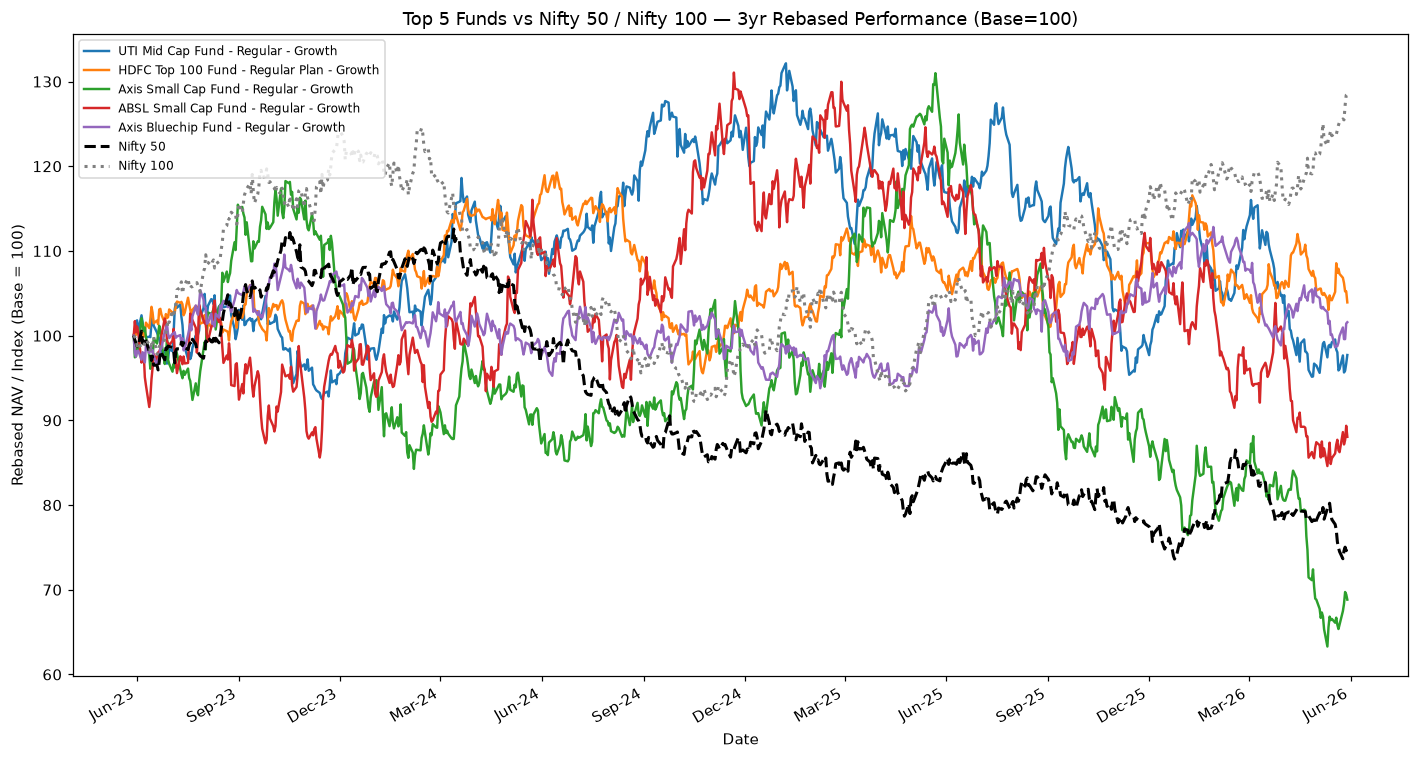

In [22]:
top5 = fund_scorecard_out.head(5).index.tolist()
print("Top 5 funds by scorecard:")
for f in top5:
    print(" -", f)

end_date = nav_wide.index.max()
start_date = end_date - pd.DateOffset(years=3)
window_nav = nav_wide.loc[nav_wide.index >= start_date, top5].dropna(how="all")
window_bench = bench.loc[bench.index >= start_date, ["nifty50", "nifty100"]]

rebased_funds = window_nav / window_nav.iloc[0] * 100
rebased_bench = window_bench / window_bench.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 7))
for col in rebased_funds.columns:
    ax.plot(rebased_funds.index, rebased_funds[col], label=col, linewidth=1.6)
ax.plot(rebased_bench.index, rebased_bench["nifty50"], label="Nifty 50", color="black", linestyle="--", linewidth=2)
ax.plot(rebased_bench.index, rebased_bench["nifty100"], label="Nifty 100", color="grey", linestyle=":", linewidth=2)

ax.set_title("Top 5 Funds vs Nifty 50 / Nifty 100 — 3yr Rebased Performance (Base=100)")
ax.set_ylabel("Rebased NAV / Index (Base = 100)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/benchmark_comparison_top5.png", dpi=150)
plt.show()


In [23]:
# ---- Tracking error vs Nifty 100 (3yr window) ----
window_fund_returns = window_nav.pct_change().dropna(how="all")
window_bench_returns = window_bench["nifty100"].pct_change().dropna()

tracking_error = {}
for col in top5:
    merged = pd.concat([window_fund_returns[col], window_bench_returns], axis=1, join="inner").dropna()
    merged.columns = ["fund", "bench"]
    diff = merged["fund"] - merged["bench"]
    tracking_error[col] = diff.std() * np.sqrt(TRADING_DAYS)

te_df = pd.Series(tracking_error, name="Tracking_Error_3yr").sort_values()
te_df.to_frame().to_csv(f"{OUTPUT_DIR}/tracking_error_top5.csv")
te_df.to_frame().style.format("{:.2%}")


,Tracking_Error_3yr
Axis Bluechip Fund - Regular - Growth,18.59%
HDFC Top 100 Fund - Regular Plan - Growth,19.54%
UTI Mid Cap Fund - Regular - Growth,22.34%
Axis Small Cap Fund - Regular - Growth,28.35%
ABSL Small Cap Fund - Regular - Growth,29.31%


## Summary of Deliverables

All written to `outputs/`:

- `fund_scorecard.csv` — composite 0–100 scorecard, all 40 funds ranked
- `alpha_beta.csv` — Alpha / Beta / R² / p-value per fund
- `cagr_comparison.csv`, `sharpe_ratio.csv`, `sortino_ratio.csv`, `max_drawdown.csv` — supporting tables
- `benchmark_comparison_top5.png` — top 5 funds vs Nifty 50 / Nifty 100 chart
- `daily_return_distribution.png` — distribution sanity check
- `tracking_error_top5.csv` — tracking error for the top 5 funds
